# <center> A clustering method: K-means</center>

The following libraries will be used

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

In [2]:
fte_colors = {0: "blue", 1: "red", 2: "darkorange", 3: "forestgreen"}

In the previous lectures we studied **supervised learning methods**: given some pairs of predictors and response, train a given algorithm to predict to good response from the predictors.

The last lecture of this serie is dedicated to introduce a **non-supervised learning** method that belong to the **clustering method**.

Clustering consists into partitioning the observations into **groups** ("clusters") so that the pairwise dissimilarities between those assigned to the same cluster tend to be smaller than those in different clusters.

<br>
<center><img src="clustering.png" width="400"></center>  

In particular, the dataset do not contain **any response or label**  

## 1-Introduction

### Picture the scenario

We consider the following dataset

In [3]:
data = pd.read_csv('data.csv',index_col=0)
#data=data.transpose()

In [4]:
data.shape

(64, 6830)

In [5]:
data.head()

,1,2,3,4,5,6,7,8,9,10,...,6821,6822,6823,6824,6825,6826,6827,6828,6829,6830
CNS,0.300000,1.180000,0.550000,1.140000,-0.265000,-7.000000e-02,0.350000,-0.315000,-0.450000,-0.654980,...,-0.990020,0.000000,0.030000,-0.175000,0.629981,-0.030000,0.000000,0.280000,-0.340000,-1.930000
CNS,0.679961,1.289961,0.169961,0.379961,0.464961,5.799610e-01,0.699961,0.724961,-0.040039,-0.285019,...,-0.270058,-0.300039,-0.250039,-0.535039,0.109941,-0.860039,-1.250049,-0.770039,-0.390039,-2.000039
CNS,0.940000,-0.040000,-0.170000,-0.040000,-0.605000,0.000000e+00,0.090000,0.645000,0.430000,0.475019,...,0.319981,0.120000,-0.740000,-0.595000,-0.270020,-0.150000,0.000000,-0.120000,-0.410000,0.000000
RENAL,0.280000,-0.310000,0.680000,-0.810000,0.625000,-1.387779e-17,0.170000,0.245000,0.020000,0.095019,...,-1.240020,-0.110000,-0.160000,0.095000,-0.350019,-0.300000,-1.150010,1.090000,-0.260000,-1.100000
BREAST,0.485000,-0.465000,0.395000,0.905000,0.200000,-5.000000e-03,0.085000,0.110000,0.235000,1.490019,...,0.554980,-0.775000,-0.515000,-0.320000,0.634980,0.605000,0.000000,0.745000,0.425000,0.145000


In [6]:
#taking 100 rows at random
df=data.sample(n=100,axis=1,random_state=2)

In [7]:
df.shape

(64, 100)

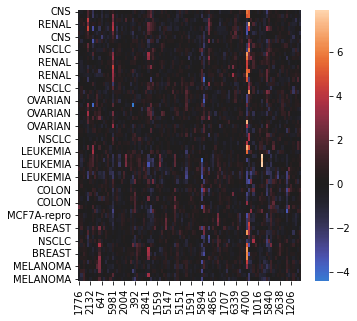

In [8]:
plt.figure(figsize=(5, 5))
sns.heatmap(df,center=0)
plt.show()

### Description of the dataset.

*Disclaimer: I am not a biologist!!*

The dataset comes from [An Introduction to Statistical Learning with Applications in R](http://www-bcf.usc.edu/~gareth/ISL/), Gareth James, Daniela Witten, Trevor Hastie and Rob Tibshirani. 

The data are a $64\times6830$ matrix of real numbers, each representing an expression measurement for a gene (column) and sample (row).

It is a **DNA expression microarrays**. A DNA expression micorarray measures the expression of a gene in a cell by mesuring the amount of mRNA present for that gene. Positive values indicate higher expression.  

Questions:
- which samples are most similar to each other, in terms of their expression profiles across genes ?
- which gene are most similar to each other, in terms of their expression profiles across samples?

## 2- K-means algorithm

K-means clustering is a simple and elegant approach for partitioning a data set into $K$ distinct, non-overlapping clusters.

Principle: generate a clustering (not too bad) and refine it until a certain stability is obtained. It is an incremental procedure.

K-means algorithm pseudo-code:

> **Input**: the number of clusters $K$
>
>**Initialization**: select at random $K$ centroids (data points representing the center of a cluster)
>
>**While (termination criteria not met) do**:
>
>1-Assign each point of the data set to the nearest centroid. Points assigned to the same centroid belong to the same cluster 
>
>2-Compute the new centrois (mean) of each cluster.
>
>**EndWhile**

### Example over a toy dataset in Pyton

In [9]:
features, true_labels = make_blobs(n_samples=30,
                                   centers=3,
                                   cluster_std=2.75,
                                   random_state=42)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [10]:
init_centers = np.array([[0.0,-0.5],
                         [0.0, 0.0],
                         [-1.0,0.0]])

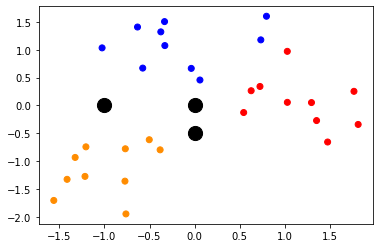

In [11]:
colors = [fte_colors[label] for label in true_labels]
plt.scatter(scaled_features[:,0],scaled_features[:,1],c=colors,cmap='brg')
plt.scatter(init_centers[:, 0], init_centers[:, 1], s=200, c='black')

D:\Program Files\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1146: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  self._check_params(X)
D:\Program Files\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1146: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  self._check_params(X)
D:\Program Files\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1146: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  self._check_params(X)
D:\Program Files\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1146: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  self._check_params(X)


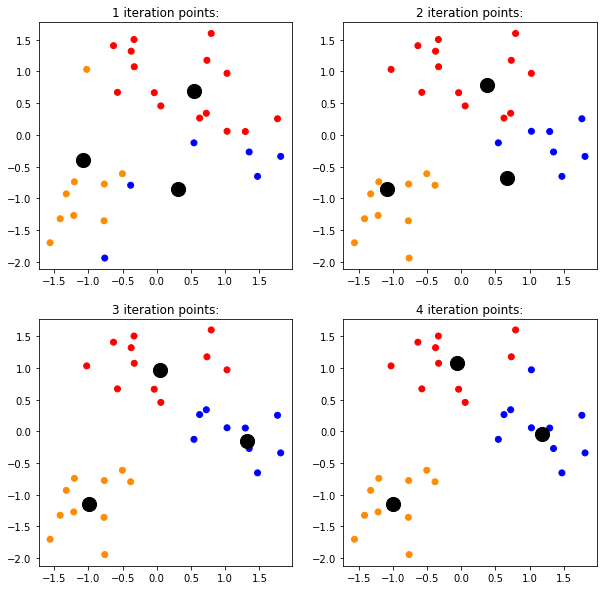

In [12]:
fig, ax = plt.subplots(nrows=2, ncols=2,figsize=(10,10))

from sklearn.cluster import KMeans
c=d=0
for i in range(4):
    ax[c,d].title.set_text(f"{i+1} iteration points:")
    kmeans = KMeans(n_clusters=3,init=init_centers,random_state=2,max_iter=i+1)
    kmeans.fit(scaled_features)
    centroids=kmeans.cluster_centers_
    km_colors = [fte_colors[label] for label in kmeans.labels_]
    ax[c,d].scatter(scaled_features[:,0],scaled_features[:,1],c=km_colors,cmap='brg')
    ax[c,d].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black')
    d+=1
    if d==2:
        c+=1
        d=0

In the Kmeans method of sklearn:
- *init* controls the initialization technique.
- *n_clusters* sets $K$ for the clustering step. This is the most important parameter for K-means.
- *n_init* sets the number of initializations to perform. This is important because two runs can converge on different cluster assignments. The default behavior for the scikit-learn algorithm is to perform ten k-means runs and return the results of the one with the lowest within-cluster inertia.
- *max_iter* sets the number of maximum iterations for each initialization of the k-means algorithm.

Termination criteria:
- maximal number of ieration
- or convergence: two successive iterations lead to the same partition.

As well, it is possible to determine to which cluster belongs a new point:

In [13]:
new=np.array([np.random.normal(0,1,size=2)])
print(new)

[[ 1.00347139 -0.4238736 ]]


In [14]:
kmeans.predict(new)

array([0])

### Theoretical background

The idea behind $K$-means clustering is that a good clustering is one for which the
**within-cluster inertia** is as small as possible. The within-cluster inertia for cluster $C_k$ is a measure $I(C_k)$ of the amount by which the observations within a cluster differ from each other. Hence we want to solve the problem

\begin{equation}\tag{1}
\text{minimize}_{C_1,\cdots,C_K}\sum_{k=1}^{K}I(C_k)
\end{equation}

In words, this formula says that we want to partition the observations into $K$ clusters such that the total within-cluster variation, summed over all $K$ clusters, is as small as possible.

Solving (1) seems like a reasonable idea, but in order to make it actionable we need to define the within-cluster variation. There are many possible ways to define this concept, but by far the most common choice involves squared Euclidean distance. That is, we define

$$I(C_k)=\frac{1}{|C_k|}\sum_{x\in C_k}\|x-\mu_k\|^2 $$

with

$$\mu_k=\frac{1}{|C_k|}\sum_{x\in C_k}x$$

where $|C_k|$ denotes the number of observations in the kth cluster. 

$\mu_k$ is the centroid of cluster $k$.

In otherwords, the within-cluster variation for the kth cluster is the sum of all of the pairwise squared Euclidean distances between the observations in the kth cluster, divided by the total number of observations in the kth cluster.

<u>Property</u>:  The within-cluster inertia decreases with the iterations of the the Kmeans algorithm.

<u>Corollary:</u> The Kmeans algorithm stops after a finite number of iterations.

Remark: Variations of Kmeans includes taking the median or another distance instead of the Euclidean one.

### How to choose K?

#### The elbow method

<u>Method</u>: Plot the within-sum of squares as a function of the number of clusters $K$. Choose the number $K$ "at the elbow" of the curve: this is the point where diminishing returns are no longer worth the additional cost.

In [15]:
features, true_labels = make_blobs(n_samples=200,
                                   centers=3,
                                   cluster_std=2.75,
                                   random_state=42)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [16]:
# A list holds the inertia values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

D:\Program Files\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


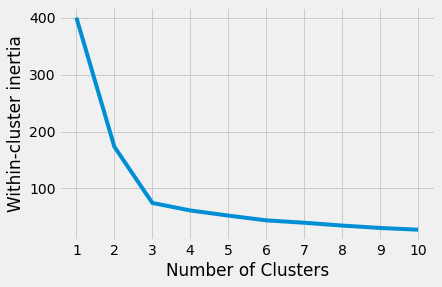

In [17]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Within-cluster inertia")
plt.show()

Determining the elbow point in the within-lcuster inertia curve isn't always straightforward. If you're having trouble choosing the elbow point of the curve, then you could
- use a Python package, 'kneed', to identify the elbow point programmatically
- or rely on the silhouette coefficient

Elbow method and silhouette coefficient are often used as complementary evaluation techniques rather than one being preferred over the other.

### Silhouette coefficient

The silhouette coefficient is a measure of cluster cohesion and separation. It quantifies how well a data point fits into its assigned cluster based on two factors:

1- How close the data point is to other points in the cluster

2 -How far away the data point is from points in other 

Silhouette coefficient values range between $-1$ and $1$. Larger numbers indicate that samples are closer to their clusters than they are to other clusters.

#### Computing the silhouette coefficient

Assume the data have been clustered via any technique, such as K-means, into $K$ clusters.

For data point $i \in C_i$ (data point $i$ in the cluster $C_i$, let

$$a(i) = \frac{1}{|C_i| - 1} \sum_{j \in C_i, i \neq j} d(i, j)$$

be the mean distance between $i$ and all other data points in the same cluster, where $|C_i|$ is the number of points belonging to cluster $i$, and $d(i, j)$ is the distance between data points $i$ and $j$ in the cluster $C_i$ (we divide by $|C_i| - 1$ because we do not include the distance $d(i, i)$ in the sum). We can interpret $a(i)$ as a measure of how well $i$ is assigned to its cluster (the smaller the value, the better the assignment).

We then define the mean dissimilarity of point $i$ to some cluster $C_k$ as the mean of the distance from $i$ to all points in $C_k$ (where $C_k \neq C_i$).

For each data point $i \in C_i$, we now define

$$b(i) = \min_{k \neq i} \frac{1}{|C_k|} \sum_{j \in C_k} d(i, j)$$

to be the ''smallest'' (hence the $\min$ operator in the formula) mean distance of $i$ to all points in any other cluster, of which <math>i</math> is not a member. The cluster with this smallest mean dissimilarity is said to be the "neighboring cluster" of $i$ because it is the next best fit cluster for point $i$.

We now define a ''silhouette'' (value) of one data point $i$

$s(i) = \frac{b(i) - a(i)}{\max\{a(i),b(i)\}}$, if $|C_i| > 1$

and

$s(i) = 0$, if $|C_i| = 1$


Note that $a(i)$ is not clearly defined for clusters with size $1$, in which case we set $s(i)=0$.

<u>Method</u>: Plot the silhouette as a function of the number of clusters $K$ and select $K$ that provides the maximal silhouette.

In [18]:
silhouette_coefficients = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    score = silhouette_score(scaled_features, kmeans.labels_)
    silhouette_coefficients.append(score)

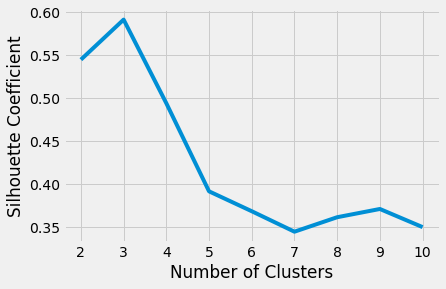

In [19]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

### Need for standardization

K-means clustering is "isotropic" in all directions of space and therefore tends to produce more or less round (rather than elongated) clusters. In this situation leaving variances unequal is equivalent to putting more weight on variables with smaller variance.

In [20]:
np.random.seed(42)
X1 = np.random.normal(0,1,size=(100, 2))+np.ones((100,2))
X2 = np.random.normal(0,1,size=(100, 2))-np.ones((100,2))
X=np.concatenate([X1,X2])

# Introduce denormalization
X[:, 1] = X[:, 1] * 1000 + 500

In [21]:
kmeans = KMeans(n_clusters=2,random_state=42)
kmeans.fit(X)
km_colors_noscale = [fte_colors[label] for label in kmeans.labels_]

In [22]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=2,random_state=42)
kmeans.fit(scaled_features)
# The k-means plot
km_colors = [fte_colors[label] for label in kmeans.labels_]

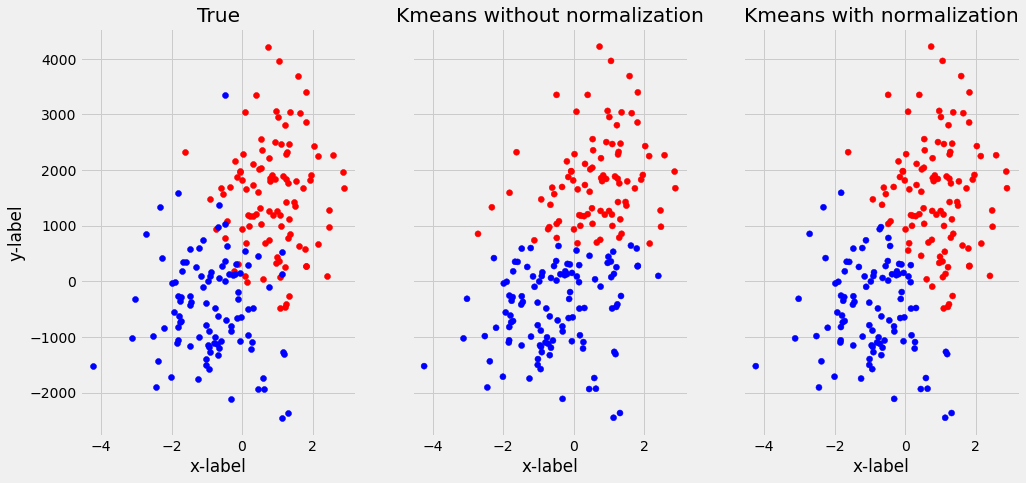

In [23]:
fig, axs = plt.subplots(1,3,figsize=(15,7))
axs[0].scatter(X[:100,0],X[:100,1],c='red')
axs[0].scatter(X[100:,0],X[100:,1],c='blue')
axs[0].set_title('True')
axs[1].scatter(X[:,0],X[:,1],c=km_colors_noscale)
axs[1].set_title('Kmeans without normalization')
axs[2].scatter(X[:,0],X[:,1],c=km_colors)
axs[2].set_title('Kmeans with normalization')

for ax in axs.flat:
    ax.set(xlabel='x-label', ylabel='y-label')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

### Risk of local convergence

There is no guarantee of global convergence. In fact, K-means depends heavily on the initialization, and may **converge locally** in case of 'bad luck'. See the folowwing example.

In [24]:
features, true_labels = make_blobs(n_samples=400,centers=4,random_state=42)

In [25]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

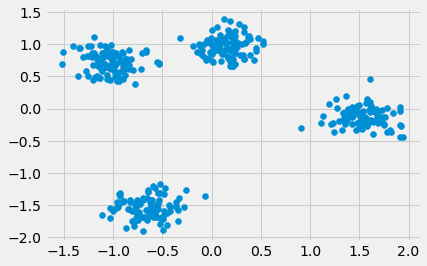

In [26]:
plt.scatter(scaled_features[:, 0], scaled_features[:, 1])

In [27]:
init_centers = np.array([[-1.5,1.0],
                         [0.0, 1.55],
                         [0.0,1.5],
                         [0,1.6]])

#init_centers = np.array([[-1.5,1.0],
#                         [-0.75, -1.55],
#                         [0.0,1.5],
#                         [1.6,0]])

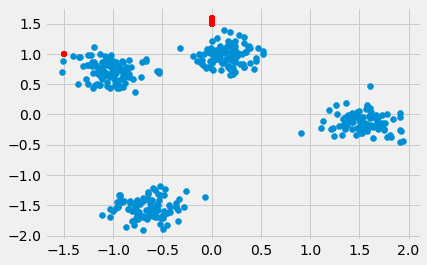

In [28]:
plt.scatter(scaled_features[:, 0], scaled_features[:, 1])
plt.scatter(init_centers[:, 0], init_centers[:, 1],marker='+',c='red')

In [29]:
kmeans = KMeans(n_clusters=4,init=init_centers)
kmeans.fit(scaled_features)

D:\Program Files\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1146: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  self._check_params(X)


KMeans(init=array([[-1.5 ,  1.  ],
       [ 0.  ,  1.55],
       [ 0.  ,  1.5 ],
       [ 0.  ,  1.6 ]]),
       n_clusters=4)

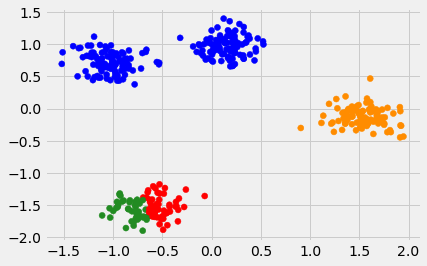

In [30]:
# The k-means plot
km_colors = [fte_colors[label] for label in kmeans.labels_]
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=km_colors)

Tips: 
- Run several times the algorithm (with random initialization each time) and keep the best run (parameter 'n_init' of the kmeans method in sklearn)
- Use other initialization methods (see parameter 'init' and the option 'k-means++' of the kmeans method in sklearn)

### The clusters found by a K-means algorithm are convex

A direct consequence is that if the data structure presents some non-convexities, a K-means algorithm is not efficient. See the following example.

In [31]:
features, true_labels = make_moons(n_samples=250, noise=0.05, random_state=42)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

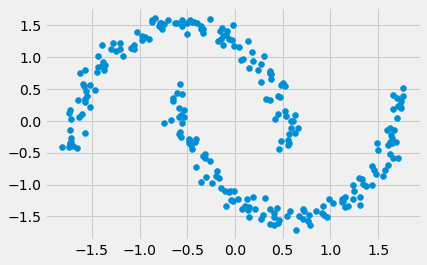

In [32]:
plt.scatter(scaled_features[:, 0], scaled_features[:, 1])

In [33]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(scaled_features)

KMeans(n_clusters=2)

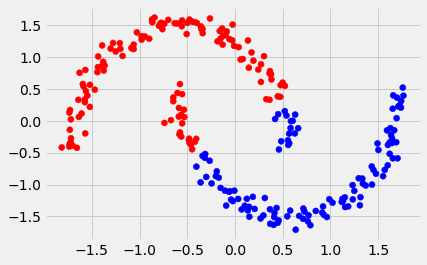

In [34]:
# The k-means plot
km_colors = [fte_colors[label] for label in kmeans.labels_]
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=km_colors)

Tip: try different clustering algorithms (some are able to find non-convex dataset, such as DBSCAN) and select the best one.

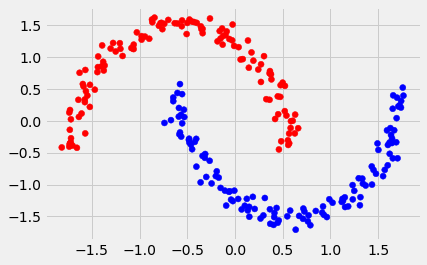

In [35]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.25).fit(features)
# The dbscan plot
dbscan_colors = [fte_colors[label] for label in dbscan.labels_]
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=dbscan_colors)
plt.show()

#### Another example

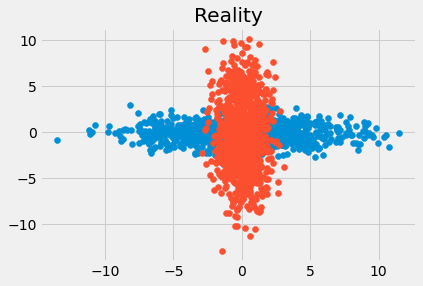

In [36]:
Test1=np.random.multivariate_normal(np.zeros(2),np.array([[15,0],[0,1]]),size=1000)
plt.scatter(Test1.T[0],Test1.T[1])
Test2=np.random.multivariate_normal(np.zeros(2),np.array([[1,0],[0,15]]),size=1000)
plt.scatter(Test2.T[0],Test2.T[1])
Test=np.concatenate((Test1,Test2),axis=0)
plt.title("Reality")
plt.show()

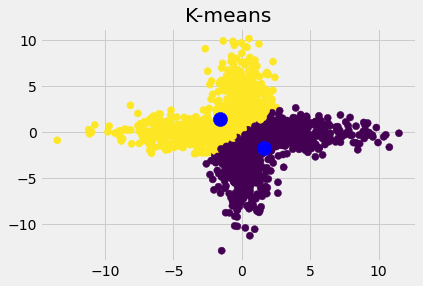

In [37]:
kmeans=KMeans(2).fit(Test)
y_kmeans = kmeans.predict(Test)
plt.scatter(Test[:, 0], Test[:, 1], c=y_kmeans, s=50)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='blue', s=200)
plt.title("K-means")
plt.show()

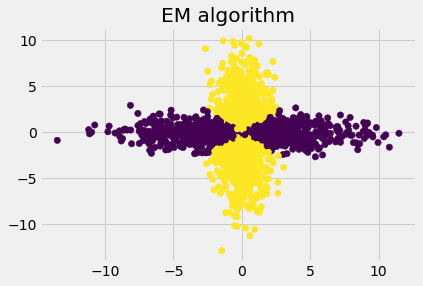

In [38]:
from sklearn.mixture import GaussianMixture as GMM

gmm = GMM(n_components=2,covariance_type='full',tol=1e-6,n_init=5).fit(Test)
labels = gmm.predict(Test)
plt.scatter(Test[:, 0], Test[:, 1], c=labels, s=40)
plt.title("EM algorithm")
plt.show()

## 3- Application to our dataset

Here we cluster the $6830$ samples.

In [39]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

### Choice of K

#### Elbow method

In [40]:
# A list holds the within cluster inertia values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

D:\Program Files\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


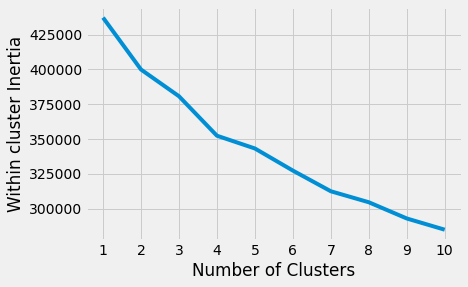

In [41]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Within cluster Inertia")
plt.show()

In [42]:
kl = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing")
kl.elbow

4

#### Silhouette coefficient

In [43]:
silhouette_coefficients = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    score = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_coefficients.append(score)

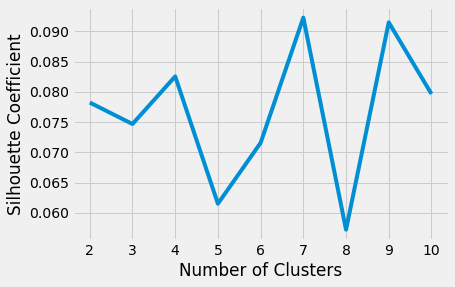

In [44]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

We choose $K=4$

In [45]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

KMeans(n_clusters=3, random_state=42)

In [46]:
kmeans.cluster_centers_.shape

(3, 6830)

In [47]:
kmeans.cluster_centers_

array([[ 0.16821506,  0.06002569, -0.02438713, ...,  0.05697959,
        -0.29064297, -0.28724212],
       [-0.39916528,  0.00220994, -0.12900887, ...,  0.30715275,
         0.82295588,  0.58222729],
       [-0.0739149 , -0.16069142,  0.18424564, ..., -0.43580219,
         0.00395454,  0.21850026]])

In [48]:
kmeans.labels_.shape

(64,)

In [49]:
print(kmeans.labels_)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2
 1 1 1 2 0 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 2 2 2 2 2 2]


In [50]:
np.unique(data.index.values)

array(['BREAST', 'CNS', 'COLON', 'K562A-repro', 'K562B-repro', 'LEUKEMIA',
       'MCF7A-repro', 'MCF7D-repro', 'MELANOMA', 'NSCLC', 'OVARIAN',
       'PROSTATE', 'RENAL', 'UNKNOWN'], dtype=object)

In [51]:
cluster=data.index.values[kmeans.labels_==2]
type,nb=np.unique(cluster,return_counts=True)

In [52]:
print(type)
print(nb)

['BREAST' 'K562A-repro' 'K562B-repro' 'LEUKEMIA' 'MELANOMA']
[2 1 1 3 7]


## 4-Conclusive remarks

(+) Easy to implement;

(+) Fast;

(+) Eficient in practice;

(-) Hyperparametrization (choice of $K$);

(-) not suitable for categorical data (relies on Eudidean distance);

(-) May converge locally;

(-) Not efficent on non-convex clusters.

<center><img src="test.jpg"></center>

- Go to [quizizz.com/join](https://quizizz.com/join)
- Enter code 2813 6158